# Cooling and Heating Workflows

This example illustrates the cooling and heating workflows currently employed by direct air capture technologies, which may also be utilised by other future RESKit implementations.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import reskit as rk

This script illustrates how to run a simulation with ETHOS.RESKit.CoolingHeating.


In [16]:
# Create Placements DataFrame with turbine locations and specifications

placements = pd.DataFrame(
    {
        "lon": [5.5, 5.994685, 6.8],
        "lat": [50.797254, 50.794208, 49.5],
        "capacity": [4000, 4000, 4000],
    }
)
placements

,lon,lat,capacity
0,5.500000,50.797254,4000
1,5.994685,50.794208,4000
2,6.800000,49.500000,4000


# Run the simulation workflow for air cooling
RESKit will run the simulation and create an xarray Dataset with the simulation results for you.
Apart from the capacity_factor, RESKit also includes the conversion factors and intermediate data used to determine the capacity factor and conversion factors.

In [17]:
reskit_xr = rk.cooling_heating.air_cooling_wenzel2025(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    temperatureCoolant=30,
    designTemperature=5,
)
reskit_xr

<xarray.Dataset> Size: 35kB
Dimensions:                             (location: 3, time: 140)
Coordinates:
  * location                            (location) int64 24B 0 1 2
  * time                                (time) datetime64[ns] 1kB 2014-12-31T...
Data variables: (12/13)
    lon                                 (location) float64 24B 5.5 5.995 6.8
    lat                                 (location) float64 24B 50.8 50.79 49.5
    capacity                            (location) int64 24B 4000 4000 4000
    surface_air_temperature             (time, location) float64 3kB -0.248 ....
    conversion_factor_fan_electricity   (time, location) float64 3kB -0.01136...
    conversion_factor_pump_electricity  (time, location) float64 3kB -0.00271...
    ...                                  ...
    capacity_factor                     (time, location) float64 3kB 1.0 ... 1.0
    conversion_factor_electricity       (time, location) float64 3kB -0.01407...
    cooling_output                      (time, location) float64 3kB 4e+03 .....
    electricity_input                   (time, location) float64 3kB 56.28 .....
    electricity_input_fan               (time, location) float64 3kB 45.45 .....
    electricity_input_pump              (time, location) float64 3kB 10.84 .....
Attributes:
    capacity:                            kW_th
    relative_cost_factor:                -
    capacity_factor:                     -
    conversion_factor_electricity:       kWh_el/kWh_th
    conversion_factor_fan_electricity:   kWh_el/kWh_th
    conversion_factor_pump_electricity:  kWh_el/kWh_th
    electricity_input:                   kWh_el
    electricity_input_fan:               kWh_el
    electricity_input_pump:              kWh_el
    cooling_output:                      kWh_th

Have a look at the previaling temperature:

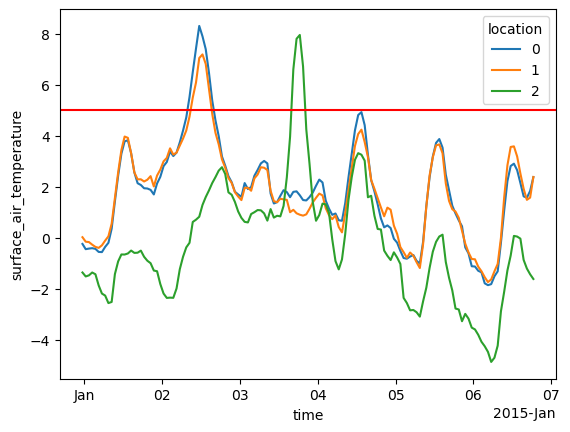

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1)
reskit_xr["surface_air_temperature"].isel(time=slice(0, 400)).plot.line(x="time", ax=ax)
ax.axhline(5, c="r")  # design Temperature, at which the system will be able to provide the specified cooling load!

RESKit will output the capacity factor of each location for every hour of the simulated year.
If the air temperature is above the design temperature, the capacity factor is lower than 1 since the designed pumps/fans would not be able to provide sufficient flows.

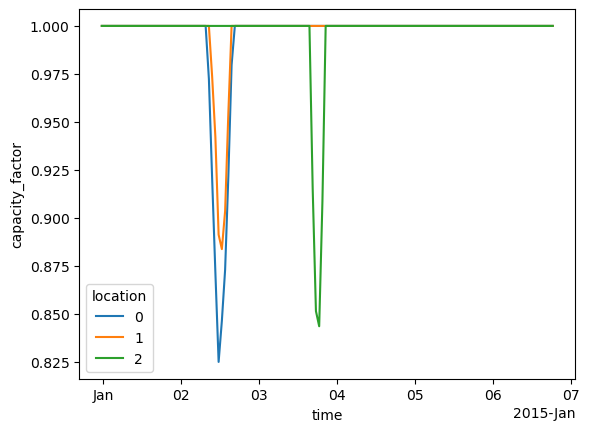

In [19]:
reskit_xr["capacity_factor"].isel(time=slice(0, 400)).plot.line(x="time")

As well as the conversion factors:

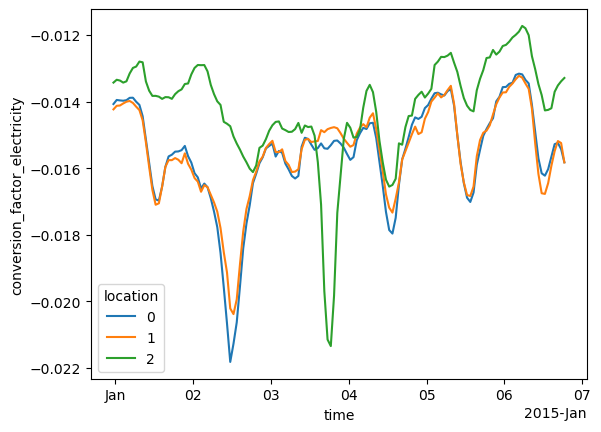

In [20]:
reskit_xr["conversion_factor_electricity"].isel(time=slice(0, 400)).plot.line(x="time")

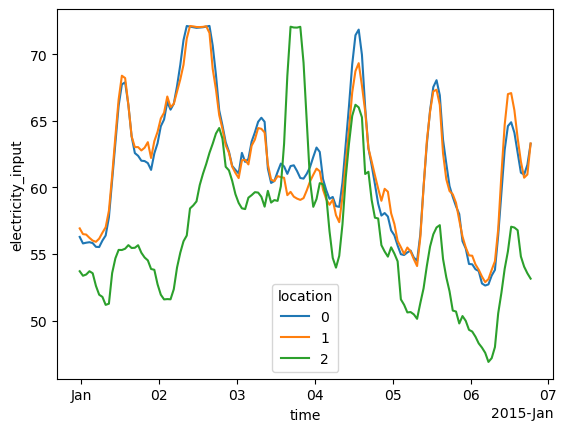

In [21]:
reskit_xr["electricity_input"].isel(time=slice(0, 400)).plot.line(x="time")

# Run the simulation workflow for an evaporative cooling system to calculate the water losses

In [22]:
reskit_xr = rk.cooling_heating.evaporative_cooling_wortmann2025(
    placements=placements,
    era5_path=rk.TEST_DATA["era5-like"],
    temperatureCoolant=80,
    heatTransferDelta=10,
    efficiencyCoolingTower=0.65,
)


reskit_xr

<xarray.Dataset> Size: 48kB
Dimensions:                                   (location: 3, time: 140)
Coordinates:
  * location                                  (location) int64 24B 0 1 2
  * time                                      (time) datetime64[ns] 1kB 2014-...
Data variables: (12/17)
    lon                                       (location) float64 24B 5.5 ... 6.8
    lat                                       (location) float64 24B 50.8 ......
    capacity                                  (location) int64 24B 4000 ... 4000
    surface_air_temperature                   (time, location) float64 3kB -0...
    surface_dew_temperature                   (time, location) float64 3kB -0...
    relative_humidity                         (time, location) float64 3kB 97...
    ...                                        ...
    specific_enthalpy_outlet                  (time, location) float64 3kB 3....
    specific_mass_evaporation_loss            (time, location) float64 3kB 0....
    specific_mass_drift_loss                  (time, location) float64 3kB 0....
    specific_mass_blowdown_loss               (time, location) float64 3kB 0....
    conversion_factor_water                   (time, location) float64 3kB -1...
    total_water_losses                        (time, location) float64 3kB 4....
Attributes:
    capacity:                                  kW_th
    conversion_factor_water:                   kg_H2O/kWh_th
    wet_bulb_temperature:                      °C
    approach_temperature_evaporative_cooling:  K
    specific_mass_evaporation_loss:            kg_H2O/kWh_th
    specific_mass_drift_loss:                  kg_H2O/kWh_th
    specific_mass_blowdown_loss:               kg_H2O/kWh_th

In [33]:
reskit_xr["conversion_factor_water"].std(dim="time")

<xarray.DataArray 'conversion_factor_water' (location: 3)> Size: 24B
array([0.03379537, 0.03082596, 0.03771017])
Coordinates:
  * location  (location) int64 24B 0 1 2

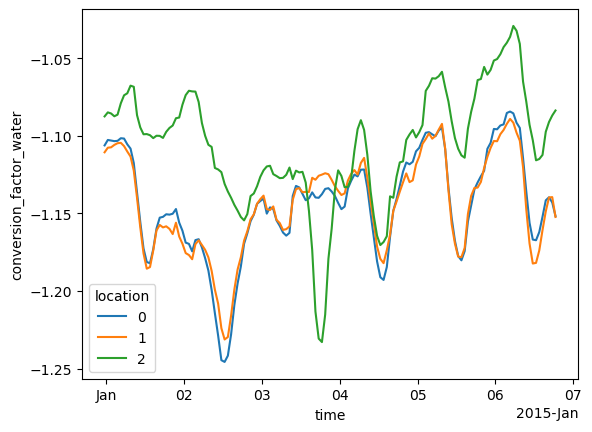

In [23]:
reskit_xr["conversion_factor_water"].isel(time=slice(0, 400)).plot.line(x="time")

The following plot show the influence of temperature vs. the conversion factor (specific water demand) for location 0:

Text(0.5, 0, 'Air Temperature [°C]')

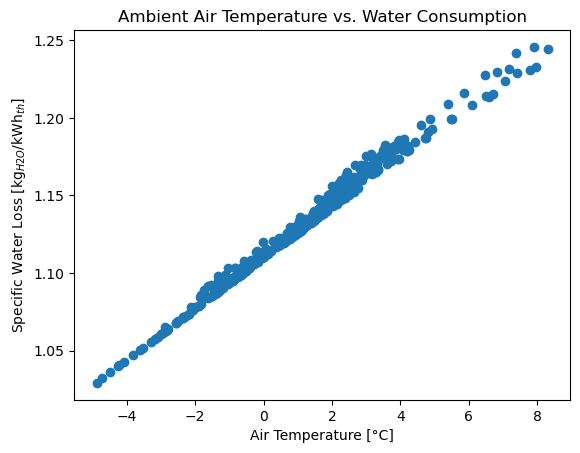

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=1, ncols=1)
ax.scatter(reskit_xr["surface_air_temperature"], -reskit_xr["conversion_factor_water"])
ax.set_title("Ambient Air Temperature vs. Water Consumption")
ax.set_ylabel("Specific Water Loss [kg$_{H2O}$/kWh$_{th}$]")
ax.set_xlabel("Air Temperature [°C]")

# Run the simulation workflow for air source heat pumps
RESKit will run the simulation and create an xarray Dataset with the simulation results for you.

In [24]:
reskit_hp = rk.cooling_heating.air_source_heat_pump(placements=placements, era5_path=rk.TEST_DATA["era5-like"])
reskit_hp

<xarray.Dataset> Size: 18kB
Dimensions:                        (location: 3, time: 140)
Coordinates:
  * location                       (location) int64 24B 0 1 2
  * time                           (time) datetime64[ns] 1kB 2014-12-31T23:30...
Data variables:
    lon                            (location) float64 24B 5.5 5.995 6.8
    lat                            (location) float64 24B 50.8 50.79 49.5
    capacity                       (location) int64 24B 4000 4000 4000
    surface_air_temperature        (time, location) float64 3kB -0.248 ... -1...
    COP                            (time, location) float64 3kB 1.861 ... 1.836
    conversion_factor_electricity  (time, location) float64 3kB -0.5373 ... -...
    electricity_input              (time, location) float64 3kB 2.149e+03 ......
    heat_output                    (time, location) float64 3kB 4e+03 ... 4e+03
Attributes:
    capacity:                       kW_th
    conversion_factor_electricity:  kWh_el/kWh_th
    electricity_input:              kWh_el
    heat_output:                    kWh_th
    COP:                            -

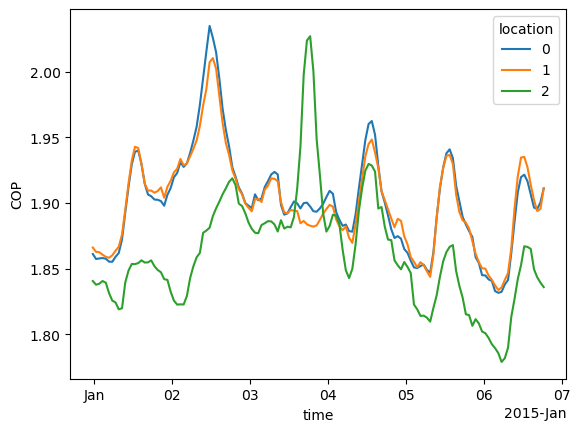

In [25]:
reskit_hp["COP"].isel(time=slice(0, 400)).plot.line(x="time")